# Feature Engineering
This notebook demonstrates the comprehensive feature engineering pipeline including:
- Sequence features (order, recency, frequency)
- Job text features (NLP-based similarity)
- Session behavior features (action patterns)

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.pipeline.data_processor import DataProcessor

sns.set_style('whitegrid')
%matplotlib inline

## 1. Load Data

In [2]:
# Initialize data processor
processor = DataProcessor()
jobs, x_train, y_train, x_test = processor.load_data()

print(f"Jobs: {len(jobs)}")
print(f"Train sessions: {len(x_train)}")
print(f"Test sessions: {len(x_test)}")

Jobs: 21917
Train sessions: 15882
Test sessions: 1819


## 2. Prepare Sequences

In [3]:
# Prepare sequences (parse lists from strings)
x_train = processor.prepare_sequences(x_train)
x_test = processor.prepare_sequences(x_test)

print("\nSample data:")
x_train.head()


Sample data:


,session_id,job_ids,actions,jobs_list,actions_list,seq_length
0,0,"[305, 299, 300, 290, 282, 274, 264, 261]","['view', 'view', 'view', 'view', 'view', 'view...","[305, 299, 300, 290, 282, 274, 264, 261]","[view, view, view, view, view, view, view, view]",8
1,1,"[84, 257, 252, 250]","['view', 'view', 'view', 'view']","[84, 257, 252, 250]","[view, view, view, view]",4
2,2,"[241, 237, 221, 309, 310, 306, 301]","['view', 'view', 'apply', 'apply', 'apply', 'a...","[241, 237, 221, 309, 310, 306, 301]","[view, view, apply, apply, apply, apply, apply]",7
3,3,"[303, 297, 296, 298, 294, 295, 292, 293]","['apply', 'apply', 'apply', 'apply', 'apply', ...","[303, 297, 296, 298, 294, 295, 292, 293]","[apply, apply, apply, apply, apply, apply, app...",8
4,4,"[171, 291, 289, 166, 288, 155]","['apply', 'apply', 'apply', 'apply', 'apply', ...","[171, 291, 289, 166, 288, 155]","[apply, apply, apply, apply, apply, apply]",6


## 3. Extract Sequence Features
Features based on order, recency, and frequency of jobs in sequences

In [4]:
# Extract sequence features only
x_train_seq = processor.add_features(x_train, feature_types=['sequence'])

# Display new sequence features
sequence_cols = [col for col in x_train_seq.columns if col not in x_train.columns]
print(f"\nSequence features added ({len(sequence_cols)}):")
print(sequence_cols)

# Show sample
x_train_seq[['session_id', 'seq_length', 'unique_jobs_count', 
             'most_frequent_job_count', 'job_transitions', 'max_consecutive_views']].head(10)

Extracting sequence features...

Sequence features added (15):
['first_job', 'last_job', 'second_job', 'second_last_job', 'unique_jobs_count', 'unique_jobs_ratio', 'most_frequent_job', 'most_frequent_job_count', 'most_frequent_job_ratio', 'job_last_positions', 'avg_job_position', 'job_transitions', 'job_transitions_ratio', 'max_consecutive_views', 'avg_consecutive_views']


,session_id,seq_length,unique_jobs_count,most_frequent_job_count,job_transitions,max_consecutive_views
0,0,8,8,1,7,1
1,1,4,4,1,3,1
2,2,7,7,1,6,1
3,3,8,8,1,7,1
4,4,6,6,1,5,1
5,5,4,4,1,3,1
6,6,4,4,1,3,1
7,7,3,3,1,2,1
8,8,6,6,1,5,1
9,9,9,9,1,8,1


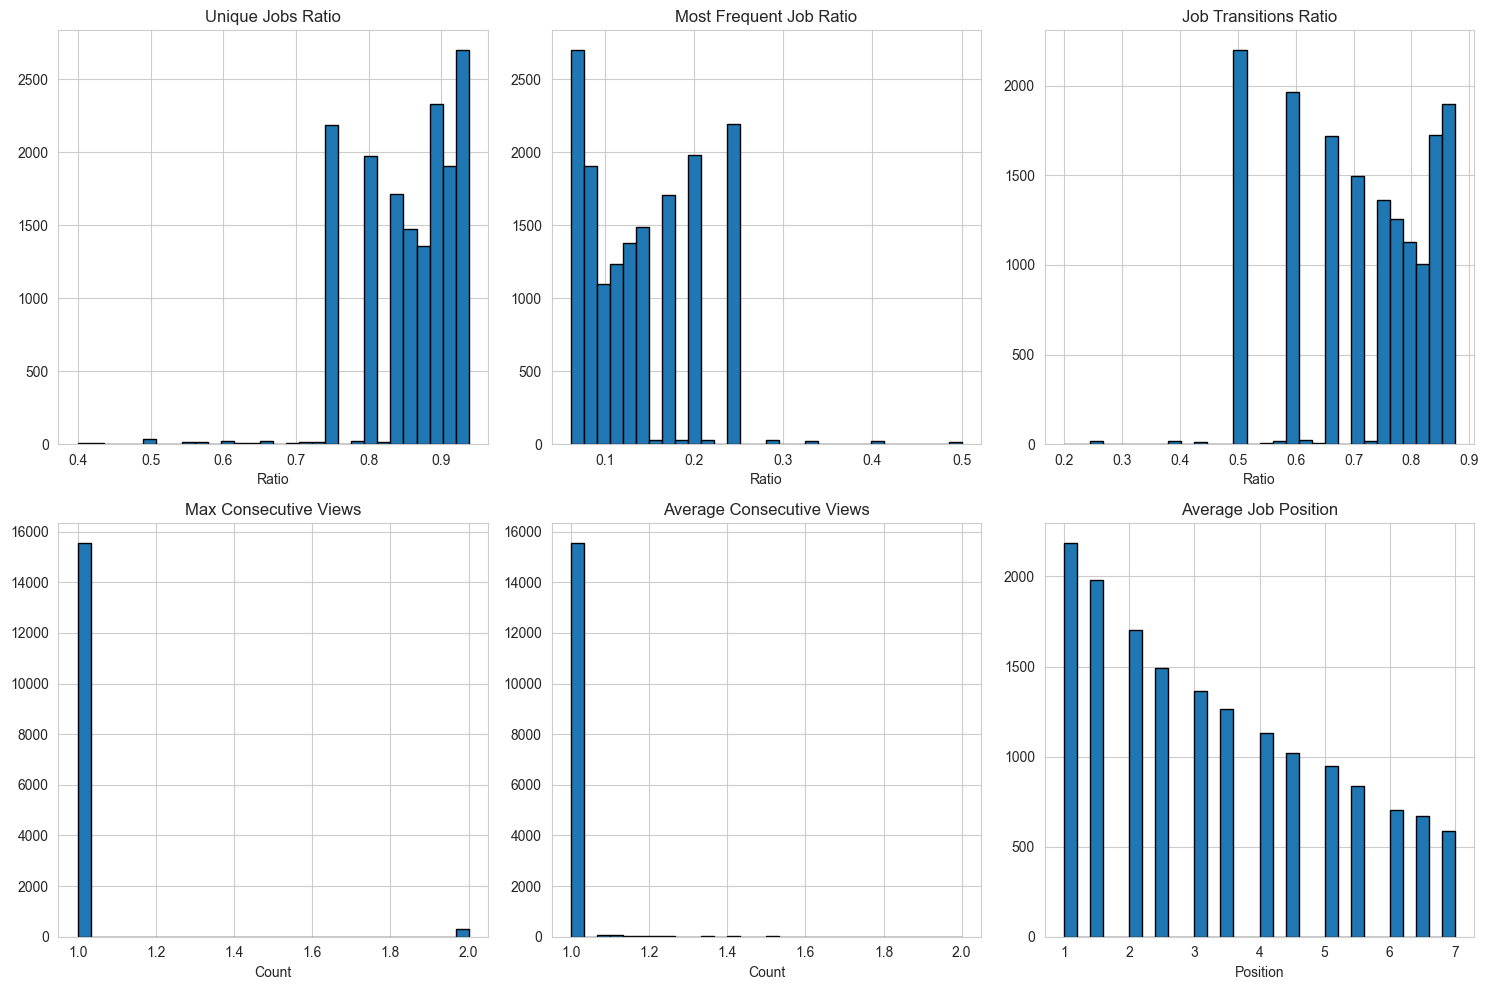

In [5]:
# Visualize sequence features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].hist(x_train_seq['unique_jobs_ratio'], bins=30, edgecolor='black')
axes[0, 0].set_title('Unique Jobs Ratio')
axes[0, 0].set_xlabel('Ratio')

axes[0, 1].hist(x_train_seq['most_frequent_job_ratio'], bins=30, edgecolor='black')
axes[0, 1].set_title('Most Frequent Job Ratio')
axes[0, 1].set_xlabel('Ratio')

axes[0, 2].hist(x_train_seq['job_transitions_ratio'], bins=30, edgecolor='black')
axes[0, 2].set_title('Job Transitions Ratio')
axes[0, 2].set_xlabel('Ratio')

axes[1, 0].hist(x_train_seq['max_consecutive_views'], bins=30, edgecolor='black')
axes[1, 0].set_title('Max Consecutive Views')
axes[1, 0].set_xlabel('Count')

axes[1, 1].hist(x_train_seq['avg_consecutive_views'], bins=30, edgecolor='black')
axes[1, 1].set_title('Average Consecutive Views')
axes[1, 1].set_xlabel('Count')

axes[1, 2].hist(x_train_seq['avg_job_position'], bins=30, edgecolor='black')
axes[1, 2].set_title('Average Job Position')
axes[1, 2].set_xlabel('Position')

plt.tight_layout()
plt.show()

## 4. Extract Session Behavior Features
Features based on user actions (view vs apply patterns)

In [6]:
# Extract session features
x_train_session = processor.add_features(x_train_seq, feature_types=['session'])

# Display new session features
session_cols = [col for col in x_train_session.columns if col not in x_train_seq.columns]
print(f"\nSession behavior features added ({len(session_cols)}):")
print(session_cols)

# Show sample
x_train_session[['session_id', 'view_count', 'apply_count', 'view_ratio', 'apply_ratio',
                 'view_to_apply_count', 'action_change_ratio']].head(10)

Extracting session behavior features...

Session behavior features added (16):
['view_count', 'apply_count', 'view_ratio', 'apply_ratio', 'first_action_is_apply', 'last_action_is_apply', 'view_to_apply_count', 'apply_to_view_count', 'action_change_ratio', 'first_apply_position', 'first_apply_position_ratio', 'applied_jobs', 'applied_jobs_count', 'unique_applied_jobs_count', 'viewed_jobs', 'viewed_not_applied_count']


,session_id,view_count,apply_count,view_ratio,apply_ratio,view_to_apply_count,action_change_ratio
0,0,8,0,0.888889,0.000000,0,0.000000
1,1,4,0,0.800000,0.000000,0,0.000000
2,2,2,5,0.250000,0.625000,1,0.142857
3,3,0,8,0.000000,0.888889,0,0.000000
4,4,0,6,0.000000,0.857143,0,0.000000
5,5,0,4,0.000000,0.800000,0,0.000000
6,6,0,4,0.000000,0.800000,0,0.000000
7,7,0,3,0.000000,0.750000,0,0.000000
8,8,0,6,0.000000,0.857143,0,0.000000
9,9,0,9,0.000000,0.900000,0,0.000000


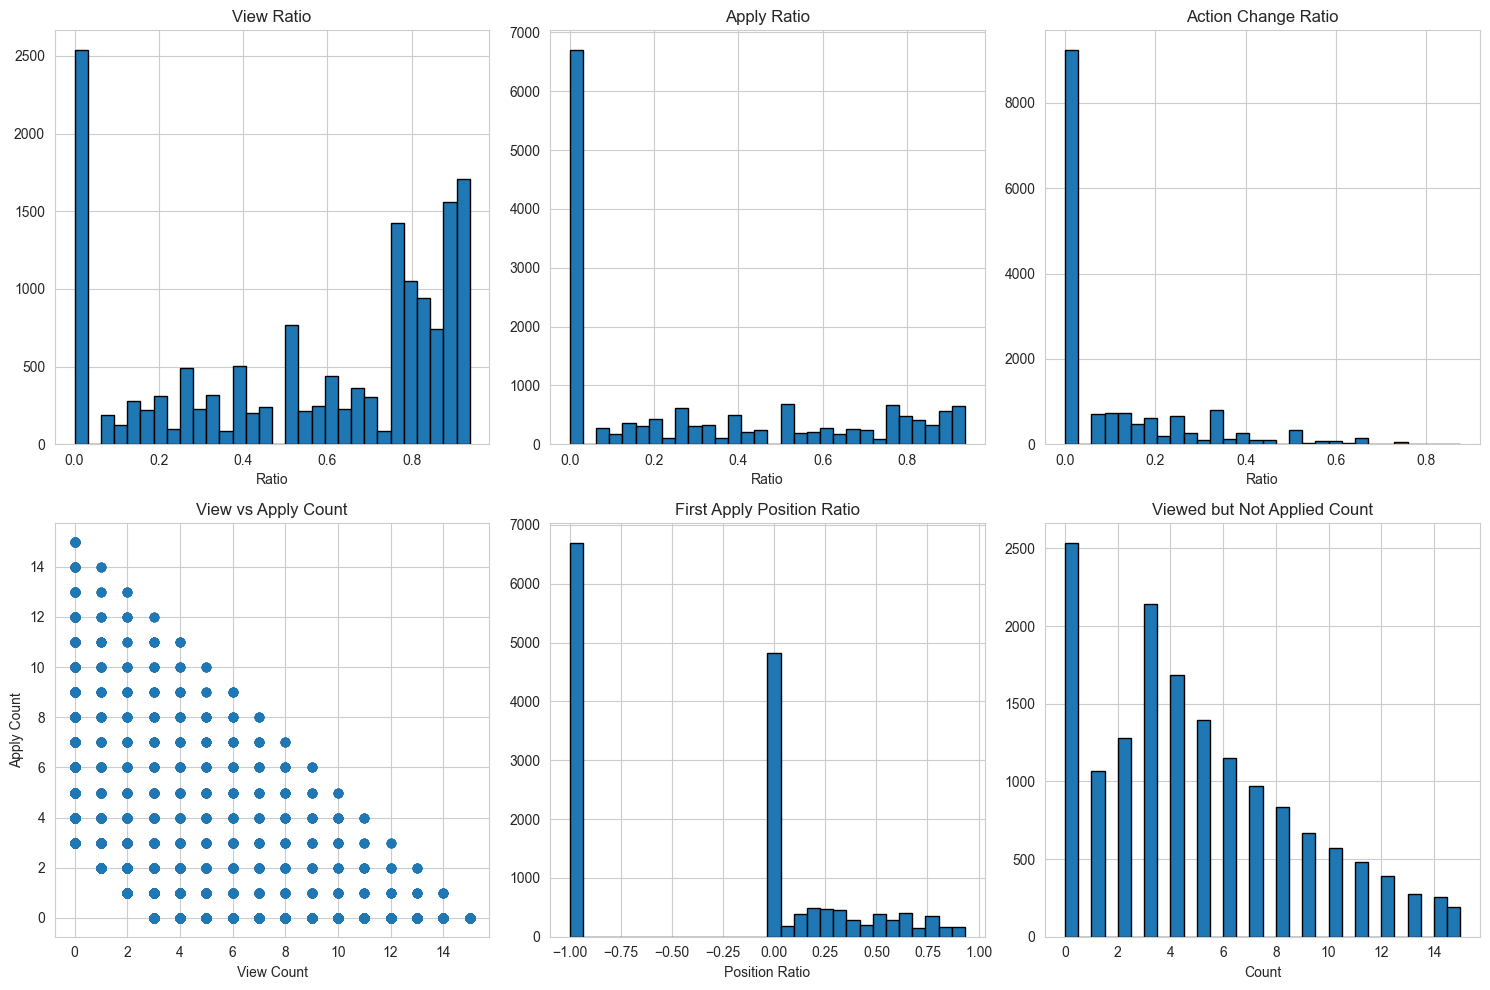

In [7]:
# Visualize session behavior features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].hist(x_train_session['view_ratio'], bins=30, edgecolor='black')
axes[0, 0].set_title('View Ratio')
axes[0, 0].set_xlabel('Ratio')

axes[0, 1].hist(x_train_session['apply_ratio'], bins=30, edgecolor='black')
axes[0, 1].set_title('Apply Ratio')
axes[0, 1].set_xlabel('Ratio')

axes[0, 2].hist(x_train_session['action_change_ratio'], bins=30, edgecolor='black')
axes[0, 2].set_title('Action Change Ratio')
axes[0, 2].set_xlabel('Ratio')

axes[1, 0].scatter(x_train_session['view_count'], x_train_session['apply_count'], alpha=0.3)
axes[1, 0].set_title('View vs Apply Count')
axes[1, 0].set_xlabel('View Count')
axes[1, 0].set_ylabel('Apply Count')

axes[1, 1].hist(x_train_session['first_apply_position_ratio'], bins=30, edgecolor='black')
axes[1, 1].set_title('First Apply Position Ratio')
axes[1, 1].set_xlabel('Position Ratio')

axes[1, 2].hist(x_train_session['viewed_not_applied_count'], bins=30, edgecolor='black')
axes[1, 2].set_title('Viewed but Not Applied Count')
axes[1, 2].set_xlabel('Count')

plt.tight_layout()
plt.show()

## 4.5. Extract Experience Level Features
Features based on seniority level (jr/sr) extracted from job descriptions

In [8]:
# Extract experience level features
x_train_exp = processor.add_features(x_train_session, feature_types=['experience'])

# Display new features
exp_cols = [col for col in x_train_exp.columns if col not in x_train_session.columns]
print(f"\nExperience level features added ({len(exp_cols)}):")
print(exp_cols)

# Show sample
x_train_exp[['session_id', 'experience_level_senior', 'experience_level_junior', 
             'experience_level_senior_ratio', 'experience_level_junior_ratio']].head(10)

Extracting experience level features...

Experience level features added (4):
['experience_level_senior', 'experience_level_junior', 'experience_level_senior_ratio', 'experience_level_junior_ratio']


,session_id,experience_level_senior,experience_level_junior,experience_level_senior_ratio,experience_level_junior_ratio
0,0,False,False,0.000000,0.0
1,1,False,False,0.000000,0.0
2,2,False,False,0.000000,0.0
3,3,False,False,0.000000,0.0
4,4,True,False,0.333333,0.0
5,5,False,False,0.000000,0.0
6,6,False,False,0.000000,0.0
7,7,False,False,0.000000,0.0
8,8,False,False,0.000000,0.0
9,9,False,False,0.000000,0.0


In [17]:
x_train_exp

,session_id,job_ids,actions,jobs_list,actions_list,seq_length,first_job,last_job,second_job,second_last_job,...,first_apply_position_ratio,applied_jobs,applied_jobs_count,unique_applied_jobs_count,viewed_jobs,viewed_not_applied_count,experience_level_senior,experience_level_junior,experience_level_senior_ratio,experience_level_junior_ratio
0,0,"[305, 299, 300, 290, 282, 274, 264, 261]","['view', 'view', 'view', 'view', 'view', 'view...","[305, 299, 300, 290, 282, 274, 264, 261]","[view, view, view, view, view, view, view, view]",8,305,261,299,264,...,-1.000000,[],0,0,"[305, 299, 300, 290, 282, 274, 264, 261]",8,False,False,0.000000,0.000000
1,1,"[84, 257, 252, 250]","['view', 'view', 'view', 'view']","[84, 257, 252, 250]","[view, view, view, view]",4,84,250,257,252,...,-1.000000,[],0,0,"[84, 257, 252, 250]",4,False,False,0.000000,0.000000
2,2,"[241, 237, 221, 309, 310, 306, 301]","['view', 'view', 'apply', 'apply', 'apply', 'a...","[241, 237, 221, 309, 310, 306, 301]","[view, view, apply, apply, apply, apply, apply]",7,241,301,237,306,...,0.285714,"[221, 309, 310, 306, 301]",5,5,"[241, 237]",2,False,False,0.000000,0.000000
3,3,"[303, 297, 296, 298, 294, 295, 292, 293]","['apply', 'apply', 'apply', 'apply', 'apply', ...","[303, 297, 296, 298, 294, 295, 292, 293]","[apply, apply, apply, apply, apply, apply, app...",8,303,293,297,292,...,0.000000,"[303, 297, 296, 298, 294, 295, 292, 293]",8,8,[],0,False,False,0.000000,0.000000
4,4,"[171, 291, 289, 166, 288, 155]","['apply', 'apply', 'apply', 'apply', 'apply', ...","[171, 291, 289, 166, 288, 155]","[apply, apply, apply, apply, apply, apply]",6,171,155,291,288,...,0.000000,"[171, 291, 289, 166, 288, 155]",6,6,[],0,True,False,0.333333,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15877,15877,"[26581, 27314, 27305, 27327, 27138, 27153]","['apply', 'apply', 'apply', 'apply', 'apply', ...","[26581, 27314, 27305, 27327, 27138, 27153]","[apply, apply, apply, apply, apply, apply]",6,26581,27153,27314,27138,...,0.000000,"[26581, 27314, 27305, 27327, 27138, 27153]",6,6,[],0,False,False,0.000000,0.000000
15878,15878,"[27220, 27219, 27194]","['view', 'view', 'view']","[27220, 27219, 27194]","[view, view, view]",3,27220,27194,27219,27219,...,-1.000000,[],0,0,"[27220, 27219, 27194]",3,False,True,0.000000,0.333333
15879,15879,"[27211, 27210, 27209]","['view', 'view', 'view']","[27211, 27210, 27209]","[view, view, view]",3,27211,27209,27210,27210,...,-1.000000,[],0,0,"[27211, 27210, 27209]",3,False,True,0.000000,0.333333
15880,15880,"[27233, 27220, 27219, 27232, 27231]","['apply', 'view', 'view', 'view', 'view']","[27233, 27220, 27219, 27232, 27231]","[apply, view, view, view, view]",5,27233,27231,27220,27232,...,0.000000,[27233],1,1,"[27220, 27219, 27232, 27231]",4,False,True,0.000000,0.200000


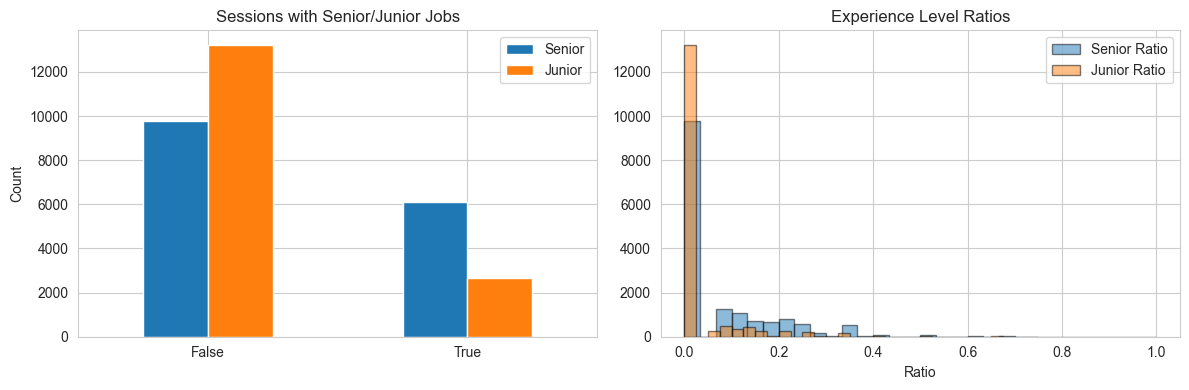

In [9]:
# Visualize experience level features
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Binary features
exp_dist = pd.DataFrame({
    'Senior': x_train_exp['experience_level_senior'].value_counts(),
    'Junior': x_train_exp['experience_level_junior'].value_counts()
})
exp_dist.plot(kind='bar', ax=axes[0])
axes[0].set_title('Sessions with Senior/Junior Jobs')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['False', 'True'], rotation=0)

# Ratio distributions
axes[1].hist(x_train_exp['experience_level_senior_ratio'], bins=30, alpha=0.5, label='Senior Ratio', edgecolor='black')
axes[1].hist(x_train_exp['experience_level_junior_ratio'], bins=30, alpha=0.5, label='Junior Ratio', edgecolor='black')
axes[1].set_title('Experience Level Ratios')
axes[1].set_xlabel('Ratio')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Extract Job Text Features (NLP)
Features based on text similarity between jobs using TF-IDF and cosine similarity

In [10]:
# Debug: Check jobs structure
print(f"Jobs type: {type(jobs)}")
print(f"Jobs length: {len(jobs)}")
if isinstance(jobs, dict):
    first_key = list(jobs.keys())[0]
    print(f"First key type: {type(first_key)}, value: {first_key}")
    print(f"First job data: {jobs[first_key]}")
elif isinstance(jobs, list):
    print(f"First job: {jobs[0]}")
    if jobs and 'JobId' in jobs[0]:
        print("Jobs is a list of dictionaries with JobId")


Jobs type: <class 'dict'>
Jobs length: 21917
First key type: <class 'str'>, value: 0
First job data: TITLE
QA Intégration / Data Analyst - SalesForces Sales Cloud 

SUMMARY
Responsabilités :
Assurer la qualité des données intégrées entre Salesforce et d'autres systèmes (SAP, autres produits).
Développer et exécuter des plans de tests pour les fonctionnalités Salesforce Sales Cloud.
Identifier, documenter et suivre les anomalies jusqu'à leur résolution.
Collaborer avec les équipes de développement pour comprendre les besoins et les spécifications.
Effectuer des analyses de données pour soutenir les décisions métier et améliorer les processus.
Participer à la qualification fonctionnelle des solutions en évolution.
Contribuer à la documentation des processus et des configurations

SECTION:
DESCRIPTION: Responsabilités :
Assurer la qualité des données intégrées entre Salesforce et d'autres systèmes (SAP, autres produits).
Développer et exécuter des plans de te

In [11]:
# Extract text features (this takes longer due to NLP processing)
print("Extracting NLP-based text features (this may take a few minutes)...")
x_train_text = processor.add_features(x_train_session.head(1000), feature_types=['text'])  # Start with subset

# Display new text features
text_cols = [col for col in x_train_text.columns if col not in x_train_session.columns]
print(f"\nText similarity features added ({len(text_cols)}):")
print(text_cols)

# Show sample
x_train_text[['session_id', 'avg_job_similarity', 'max_job_similarity', 
              'first_last_similarity', 'avg_skills_count', 'total_skills_count']].head(10)

Extracting NLP-based text features (this may take a few minutes)...
Extracting job text features with NLP...
Building TF-IDF matrix for job descriptions...
TF-IDF matrix built: (21917, 1000)

Text similarity features added (9):
['avg_job_similarity', 'max_job_similarity', 'min_job_similarity', 'first_last_similarity', 'avg_skills_count', 'total_skills_count', 'has_finance_job', 'has_tech_job', 'has_management_job']


,session_id,avg_job_similarity,max_job_similarity,first_last_similarity,avg_skills_count,total_skills_count
0,0,0.278801,0.447632,0.357106,12.200000,55
1,1,0.260750,0.351441,0.274624,11.000000,38
2,2,0.286276,0.369298,0.403028,5.000000,27
3,3,0.268602,0.328246,0.272813,9.750000,55
4,4,0.306206,0.407158,0.377097,5.166667,29
5,5,0.233902,0.319201,0.386412,6.500000,19
6,6,0.269989,0.395575,0.242530,7.000000,22
7,7,0.205360,0.243298,0.297048,6.666667,19
8,8,0.290271,0.304606,0.213329,5.500000,22
9,9,0.244262,0.323759,0.272811,8.111111,52


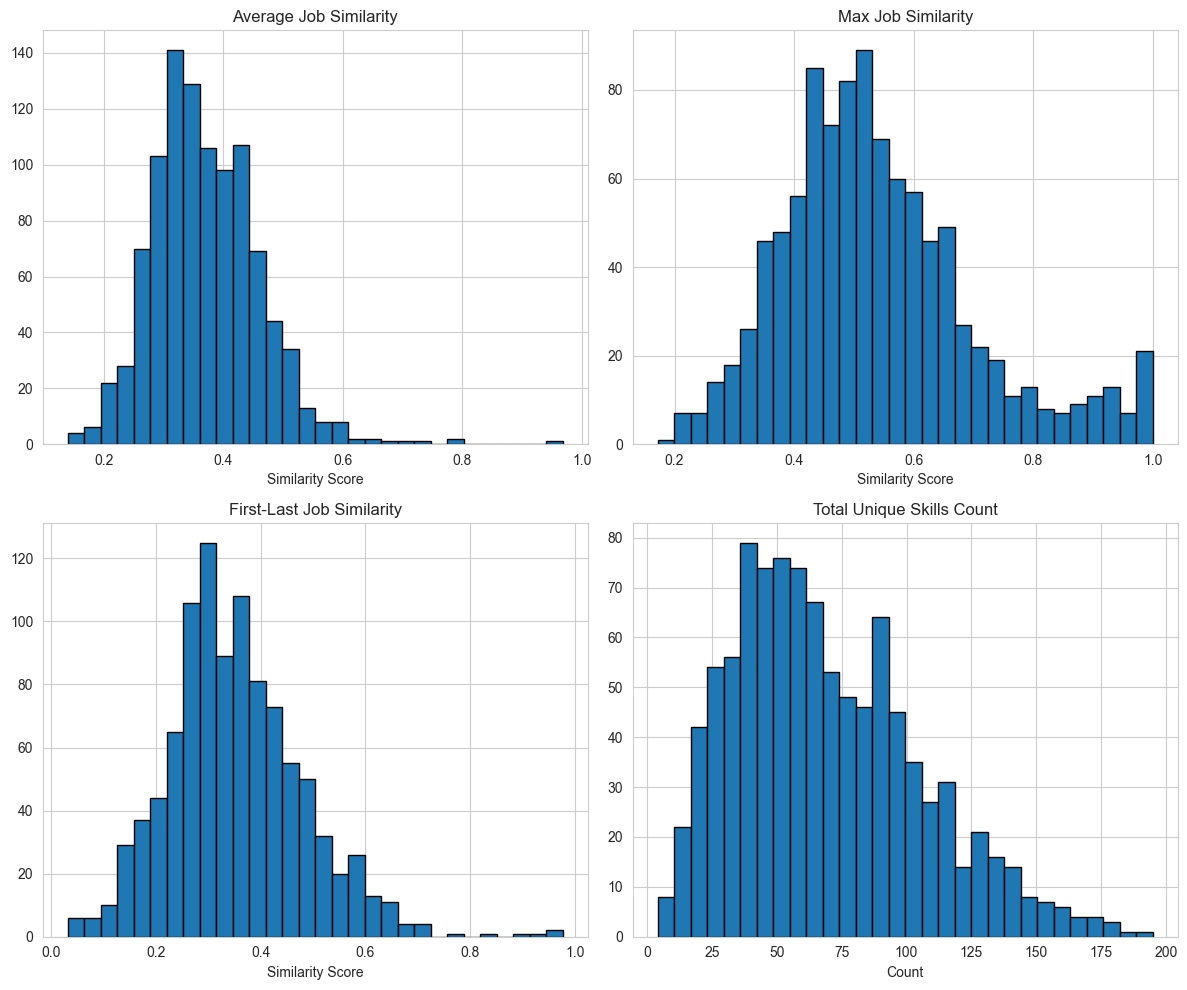

In [12]:
# Visualize text similarity features
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].hist(x_train_text['avg_job_similarity'], bins=30, edgecolor='black')
axes[0, 0].set_title('Average Job Similarity')
axes[0, 0].set_xlabel('Similarity Score')

axes[0, 1].hist(x_train_text['max_job_similarity'], bins=30, edgecolor='black')
axes[0, 1].set_title('Max Job Similarity')
axes[0, 1].set_xlabel('Similarity Score')

axes[1, 0].hist(x_train_text['first_last_similarity'], bins=30, edgecolor='black')
axes[1, 0].set_title('First-Last Job Similarity')
axes[1, 0].set_xlabel('Similarity Score')

axes[1, 1].hist(x_train_text['total_skills_count'], bins=30, edgecolor='black')
axes[1, 1].set_title('Total Unique Skills Count')
axes[1, 1].set_xlabel('Count')

plt.tight_layout()
plt.show()

## 6. Extract All Features at Once

In [13]:
# Extract all features for a small sample first
print("Extracting all features for training set (sample)...")
x_train_all = processor.add_features(x_train.head(500), feature_types=['all'])

print(f"\nOriginal columns: {x_train.shape[1]}")
print(f"With all features: {x_train_all.shape[1]}")
print(f"New features added: {x_train_all.shape[1] - x_train.shape[1]}")

# Show all column names
print("\nAll feature columns:")
for col in x_train_all.columns:
    print(f"  - {col}")

Extracting all features for training set (sample)...
Extracting sequence features...
Extracting session behavior features...
Extracting job text features with NLP...

Original columns: 6
With all features: 46
New features added: 40

All feature columns:
  - session_id
  - job_ids
  - actions
  - jobs_list
  - actions_list
  - seq_length
  - first_job
  - last_job
  - second_job
  - second_last_job
  - unique_jobs_count
  - unique_jobs_ratio
  - most_frequent_job
  - most_frequent_job_count
  - most_frequent_job_ratio
  - job_last_positions
  - avg_job_position
  - job_transitions
  - job_transitions_ratio
  - max_consecutive_views
  - avg_consecutive_views
  - view_count
  - apply_count
  - view_ratio
  - apply_ratio
  - first_action_is_apply
  - last_action_is_apply
  - view_to_apply_count
  - apply_to_view_count
  - action_change_ratio
  - first_apply_position
  - first_apply_position_ratio
  - applied_jobs
  - applied_jobs_count
  - unique_applied_jobs_count
  - viewed_jobs
  - view

## 7. Feature Statistics Summary

In [14]:
# Get numeric columns only
numeric_cols = x_train_all.select_dtypes(include=[np.number]).columns
feature_cols = [col for col in numeric_cols if col not in ['session_id', 'seq_length']]

# Summary statistics
print("Feature Statistics Summary:")
x_train_all[feature_cols].describe().T

Feature Statistics Summary:


,count,mean,std,min,25%,50%,75%,max
first_job,500.0,1718.114000,1718.377819,1.000000,454.500000,1032.500000,2397.500000,7296.000000
last_job,500.0,1435.562000,1526.594822,10.000000,338.000000,873.000000,1901.750000,7294.000000
second_job,500.0,1726.332000,1719.839344,10.000000,469.500000,965.000000,2567.750000,7295.000000
second_last_job,500.0,1471.820000,1529.056033,9.000000,410.250000,836.500000,2143.250000,7509.000000
unique_jobs_count,500.0,7.770000,3.587596,3.000000,5.000000,7.000000,11.000000,15.000000
unique_jobs_ratio,500.0,0.861514,0.064204,0.428571,0.833333,0.875000,0.916667,0.937500
most_frequent_job,500.0,1720.212000,1721.406991,1.000000,445.500000,1032.500000,2405.250000,7296.000000
most_frequent_job_count,500.0,1.012000,0.108994,1.000000,1.000000,1.000000,1.000000,2.000000
most_frequent_job_ratio,500.0,0.137248,0.059398,0.062500,0.083333,0.125000,0.166667,0.285714
avg_job_position,500.0,3.397000,1.793411,1.000000,2.000000,3.000000,5.000000,7.000000


## 8. Feature Correlation Analysis

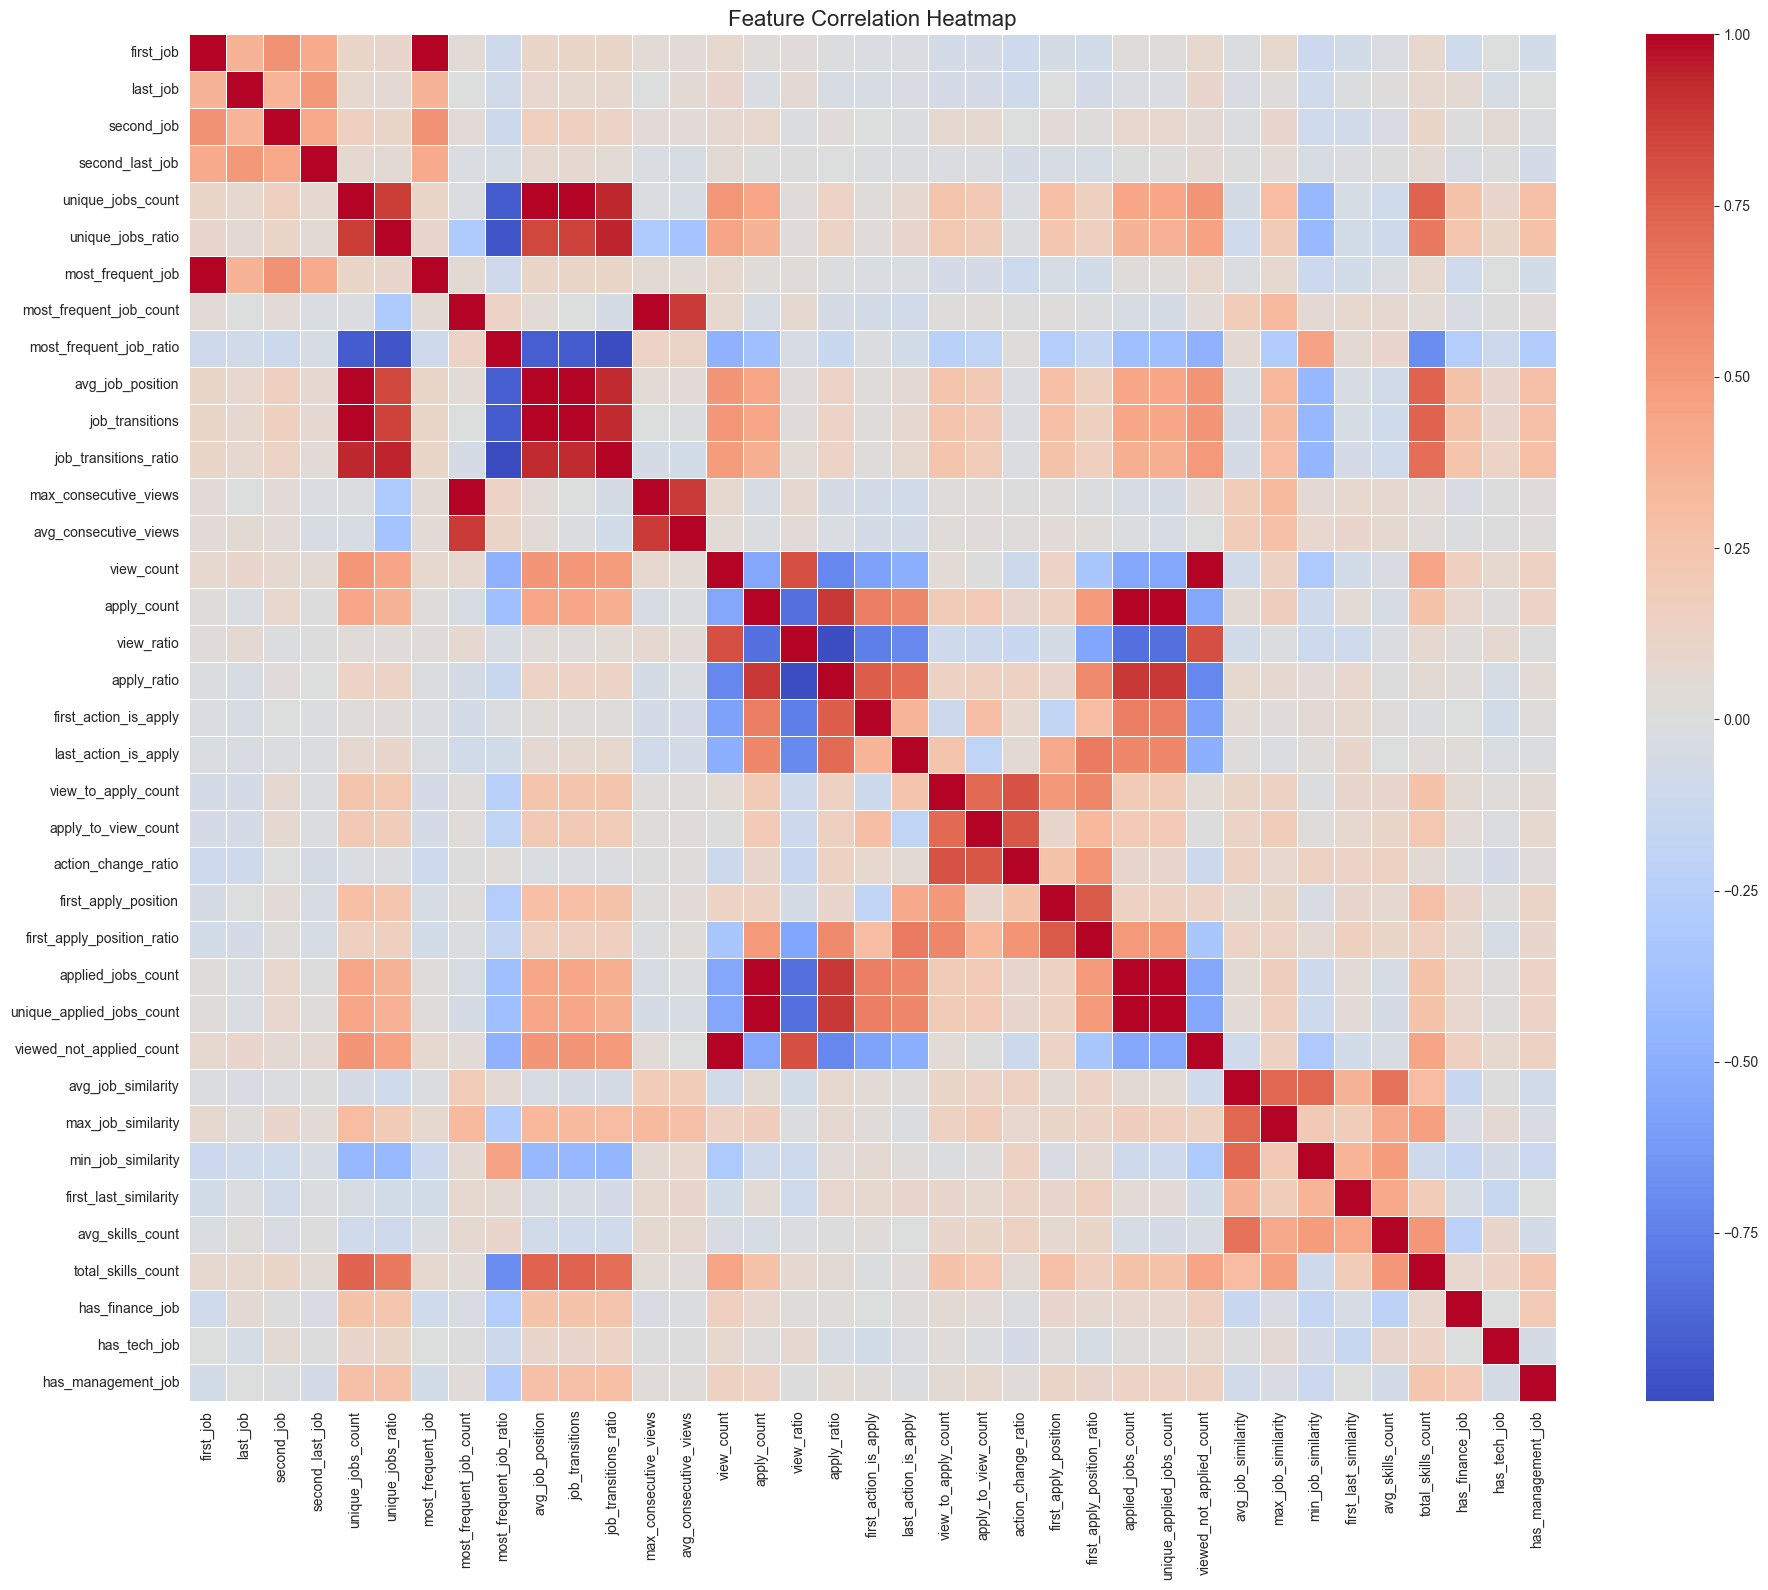

In [15]:
# Calculate correlation matrix for numeric features
correlation_matrix = x_train_all[feature_cols].corr()

# Plot heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

## 9. Save Processed Features

In [16]:
# Process full datasets (may take time)
print("Processing full training set...")
x_train_features = processor.add_features(x_train, feature_types=['sequence', 'session'])

print("Processing test set...")
x_test_features = processor.add_features(x_test, feature_types=['sequence', 'session'])

# Save to CSV
x_train_features.to_csv('../Data/x_train_with_features.csv', index=False)
x_test_features.to_csv('../Data/x_test_with_features.csv', index=False)

print("\nFeatures saved!")
print(f"Training set: {x_train_features.shape}")
print(f"Test set: {x_test_features.shape}")

Processing full training set...
Extracting sequence features...
Extracting session behavior features...
Processing test set...
Extracting sequence features...
Extracting session behavior features...

Features saved!
Training set: (15882, 37)
Test set: (1819, 37)
